# Capítulo 4: Modelos probabilísticos contínuos

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [2]:
# Pág. 125
import numpy as np
np.random.seed(100)
ns = 100 # número de simulações
a = 0; b = 15 # parâmetros da distribuição uniforme
t = 12.5 # tempo de espera (12,5 minutos)
sucesso = 0
for i in range(ns):
    if(np.random.uniform(a,b) <= t): 
        # se o tempo for menor do que t
        sucesso = sucesso + 1
print("P(X < %1.1f) = " % (t), sucesso/ns)

P(X < 12.5) =  0.85


In [3]:
# Pág. 126
import numpy as np
np.random.seed(100)
ns = 100 #número de simulações
a = 0; b = 15 # parâmetros da distribuição uniforme
t = []
for i in range(ns):
    ti = np.random.uniform(a,b)
    t.append(ti)
print("E[X]=", np.mean(t))
print("std(X)=", np.std(t))

E[X]= 7.085501875788817
std(X)= 4.338424196729057


In [4]:
# Pág. 131
import scipy.stats as st

media = 165
dp = 3 # desvio padrão
z = (162-media)/dp
print('Z:', z)
print('P(X < 162) = ', st.norm.cdf(z))

Z: -1.0
P(X < 162) =  0.15865525393145707


In [5]:
# Pág. 132
import scipy.stats as st

media = 10
dp = 2
z = (13-media)/dp
print('Z:', z)
print('P(X > 13)=', 1-st.norm.cdf(z))

Z: 1.5
P(X > 13)= 0.06680720126885809


In [6]:
# Pág. 133
import scipy.stats as st

media = 5
dp = 2
z1 = (4-media)/dp
z2 = (6-media)/dp
print('P(4 < X < 6)=', st.norm.cdf(z2)- st.norm.cdf(z1))

P(4 < X < 6)= 0.38292492254802624


In [7]:
# Pág. 134
import scipy.stats as st

media = 70
dp = 5
z1 = (65-media)/dp
z2 = (75 -media)/dp
print('z1=',z1,'z2=',z2)
print('Probabilidade:',st.norm.cdf(z2)-st.norm.cdf(z1))

z1= -1.0 z2= 1.0
Probabilidade: 0.6826894921370859


In [8]:
# Pág. 134
import numpy as np
np.random.seed(100)
media = 70
dp = 5
n = 100
# gera n valores de uma distribuição normal
X = np.random.normal(media, dp, n)
m = 0 # número de casos no intervalo
for x in X:
    # verifica se x está no intervalo
    if (x > 65 and x < 75):
        m = m + 1
print('P(65< X < 75)=', m/n)

P(65< X < 75)= 0.67


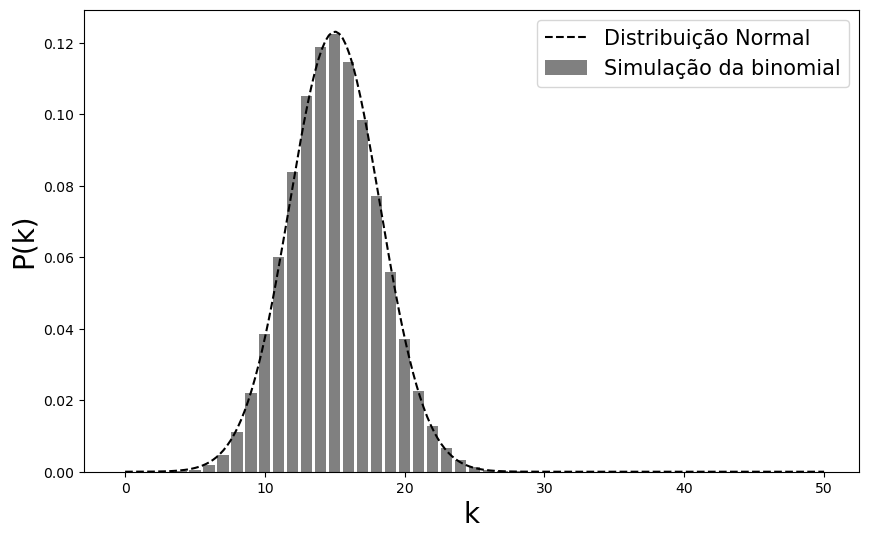

In [9]:
# Pág. 135
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import binom
from scipy.stats import norm
np.random.seed(42)

n = 50 # número de lançamentos
p = 0.3 # probabilidade de sucesso
vk = np.arange(0,n) # k varia de 0 a n
Pk = np.zeros(n) # dist. binomial
for k in vk:
    # prob. de k sucessos em n tentativas
    Pk[k] = binom.pmf(k, n, p)
plt.figure(figsize=(10,6))
plt.bar(vk, Pk, label='Simulação da binomial', 
        color = 'gray')

# curva normal 
x = np.linspace(0,n,200)
mean = n*p
sigma = np.sqrt(n*(1-p)*p)
# gera dados da normal
pdf = norm.pdf(x,mean,sigma)
plt.plot(x, pdf, linestyle = '--', 
         color = 'black', label='Distribuição Normal')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)
plt.legend(fontsize = 15)
plt.show(True)

In [10]:
# Pág. 139
import numpy as np
np.random.seed(100)

lbd = 0.5 # taxa
x = 3 # tempo de espera
ns = 100 # número de simulações
m = 0 # número de sucessos
for s in range(0,ns):
    t = np.random.exponential(1/lbd)
    if(t > x):
        m = m + 1
print('P(X > %d) = %s' % (x, m/ns))

P(X > 3) = 0.21


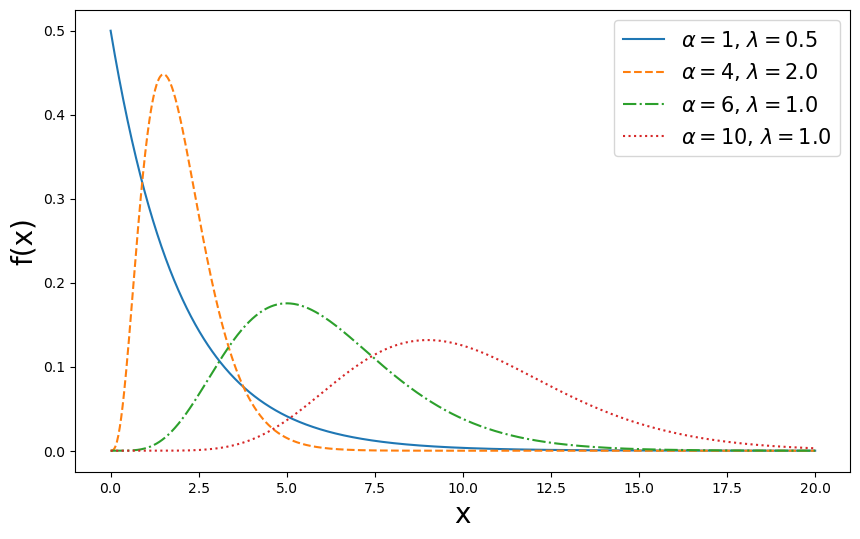

In [12]:
# Pág. 143
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':'] 
# parâmetros da distribuição
parameters = [[1,0.5],[4,2],[6,1],[10,1]]
x = np.linspace(0,20, 1000)
aux = 0
for i in parameters:
    alpha, lbd = i
    shape = alpha
    scale = 1/lbd
    dist = gamma.pdf(x, a=shape, scale=scale)
    plt.plot(x, dist, label=r'$\alpha=$'+str(shape)+r', $\lambda=$'+str(1/scale), ls=styl_list[aux])
    aux = aux + 1
plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.show()

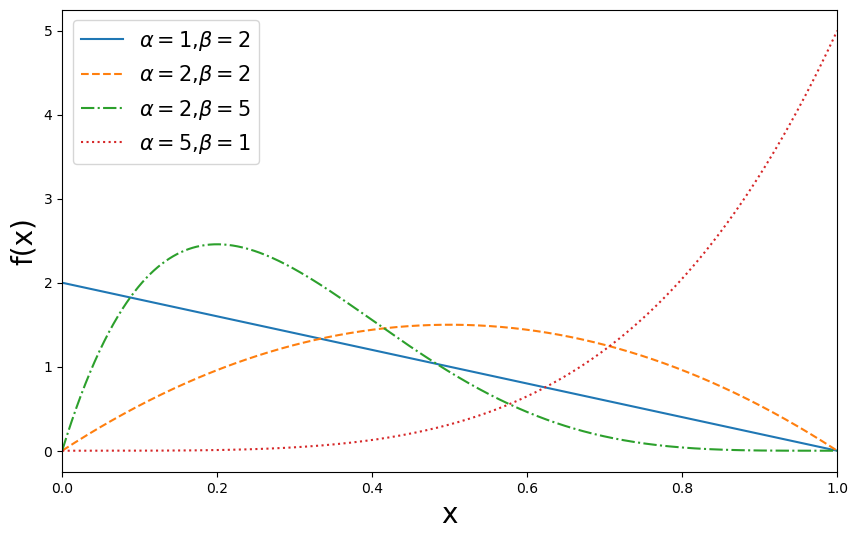

In [13]:
# Pág. 147
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':'] 
plt.xlim(0, 1)
# parâmetros da distribuição
parameters = [[1,2],[2,2],[2,5],[5,1]]
x = np.linspace(0,1, 1000)
aux = 0
for i in parameters:
    a,b = i
    plt.plot(x,beta.pdf(x, a, b), 
             label=r'$\alpha=$'+str(a)+
             r',$\beta=$'+str(b), 
             ls=styl_list[aux])
    aux = aux + 1

plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.show()

In [14]:
# Pág. 153
from scipy.stats import norm

n=500 # tamanho da amostra
p=0.46 # probabilidade
mu=n*p # média
sigma=(n*p*(1-p))**0.5 # desvio padrão
x = 250
z=(x-mu)/sigma # calcula z
prob = norm.cdf(z) 
print("Probabilidade:", norm.cdf(z)) 

Probabilidade: 0.9636417788601217
